## 4.1 Data Exploration and Cleaning ##

### Convert birthdate to date ###

In [74]:
athletes_data['birth_date']

0        10/21/1991
1         1/22/1999
2        12/21/1996
3        11/22/1999
4        10/27/1999
            ...    
11108     6/11/2003
11109     4/27/2000
11110     6/19/1999
11111    11/15/1980
11112     6/30/2004
Name: birth_date, Length: 11113, dtype: object

In [75]:
type(athletes_data['birth_date'][0])

str

In [76]:
athletes_data['birth_date'] = pd.to_datetime(athletes_data['birth_date'],errors='coerce')

### Use birthdate to create age field ###

In [78]:
athletes_data['age'] = 2024-athletes_data['birth_date'].dt.year
athletes_data.head(1)

,code,current,name,name_short,name_tv,gender,function,country_code,country,country_long,...,lang,coach,reason,hero,influence,philosophy,sporting_relatives,ritual,other_sports,age
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,...,"Armenian, English, Russian","Gevorg Aleksanyan (ARM), father",He followed his father and his uncle into the ...,"Footballer Zinedine Zidane (FRA), World Cup wi...","His father, Gevorg Aleksanyan","""Wrestling is my life."" (mediamax.am. 18 May 2...",NaN,NaN,NaN,33


### Merge all 3 datasets ###

In [80]:
athletes_medallists = pd.merge(athletes_data, medallists_data, left_on='code', right_on='code_athlete', how='left')
gdp_df = gdp_data[['Country Name','Country Code','2023']]

ath_med_gdp = pd.merge(athletes_medallists, gdp_df, left_on='country_code_x', right_on='Country Code', how='left')

### Standardize disciplines field ###

In [82]:
ath_med_gdp['disciplines'] = (
    ath_med_gdp['disciplines']
    .astype(str)                                
    .str.replace(r"[\[\]'\"`]", "", regex=True)  
    .str.strip())

ath_med_gdp['disciplines'] = ath_med_gdp['disciplines'].str.split(r',\s*')
ath_med_gdp = ath_med_gdp.explode('disciplines').reset_index(drop=True)

In [83]:
athletes_medallists.head(1)

,code,current,name_x,name_short,name_tv,gender_x,function,country_code_x,country_x,country_long_x,...,team,team_gender,discipline,event,event_type,url_event,birth_date_y,code_athlete,code_team,is_medallist
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,...,NaN,NaN,Wrestling,Men's Greco-Roman 97kg,HATH,/en/paris-2024/results/wrestling/men-s-greco-r...,10/21/1991,1532872.0,NaN,True


In [84]:
gdp_df.head(1)

,Country Name,Country Code,2023
0,Aruba,ABW,3.648573e+09


### Drop unnecessary columns ###

In [86]:
ath_med_gdp = ath_med_gdp.drop(columns=['url_event', 'philosophy', 'influence', 'hero', 'reason', 'coach', 'lang', 'family', 
                                        'nickname','hobbies', 'medal_code', 'education', 'ritual', 'sporting_relatives', 
                                        'medal_date', 'code_team', 'event'])
pd.options.display.max_columns = None
ath_med_gdp.head(1)

,code,current,name_x,name_short,name_tv,gender_x,function,country_code_x,country_x,country_long_x,nationality_x,nationality_long_x,nationality_code_x,height,weight,disciplines,events,birth_date_x,birth_place,birth_country,residence_place,residence_country,occupation,other_sports,age,medal_type,name_y,gender_y,country_code_y,country_y,country_long_y,nationality_code_y,nationality_y,nationality_long_y,team,team_gender,discipline,event_type,birth_date_y,code_athlete,is_medallist,Country Name,Country Code,2023
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,Armenia,Armenia,ARM,0.0,0.0,Wrestling,"[""Men's Greco-Roman 97kg""]",1991-10-21,GYUMRI,Armenia,GYUMRI,Armenia,Athlete,NaN,33,Silver Medal,ALEKSANYAN Artur,Male,ARM,Armenia,Armenia,ARM,Armenia,Armenia,NaN,NaN,Wrestling,HATH,10/21/1991,1532872.0,True,Armenia,ARM,2.408575e+10


### Drop duplicates ###

In [88]:
import numpy as np

ath_med_gdp = ath_med_gdp.drop_duplicates(subset=['name_x'], keep='first')

### Build a dataset of countries that shows their GDP alongside with their count of athletes and medals ###

In [90]:
athlete_medal_summary = ath_med_gdp.groupby('nationality_x').agg(
    GDP=('2023', 'first'),  
    count_of_athletes_sent=('name_x', 'nunique'),  
    count_of_medals_won=('medal_type', lambda x: x.notna().sum()) 
).reset_index()
print(athlete_medal_summary)

    nationality_x           GDP  count_of_athletes_sent  count_of_medals_won
0     Afghanistan  1.723305e+10                      11                    0
1         Albania  2.354718e+10                       8                    2
2         Algeria           NaN                      46                    3
3         Andorra  3.785067e+09                       2                    0
4          Angola           NaN                      25                    0
..            ...           ...                     ...                  ...
192     Venezuela           NaN                      32                    0
193       Vietnam           NaN                      16                    0
194         Yemen           NaN                       4                    0
195        Zambia           NaN                      31                    1
196      Zimbabwe           NaN                       7                    0

[197 rows x 4 columns]


## 4.2 Descriptive Statistics and Trends ##

### Summary statistics: Age, Gender, Height, Weight (All Athletes) ###

In [93]:
ath_med_gdp['age'].describe().round(2)

count    11103.00
mean        26.97
std          5.41
min         12.00
25%         23.00
50%         26.00
75%         30.00
max         70.00
Name: age, dtype: float64

In [94]:
gender_counts = ath_med_gdp['gender_x'].value_counts(normalize=True).round(4) * 100
print("Proportion of genders of athletes:")
print(gender_counts)

Proportion of genders of athletes:
gender_x
Male      50.92
Female    49.08
Name: proportion, dtype: float64


In [95]:
print("Summary statistics of height (cm):")
ath_med_gdp['height'].describe().round(2)

Summary statistics of height (cm):


count    11100.00
mean        81.79
std         89.51
min          0.00
25%          0.00
50%          0.00
75%        177.00
max        222.00
Name: height, dtype: float64

In [96]:
print("Summary statistics of weight (kg):")
ath_med_gdp['weight'].describe().round(2)

Summary statistics of weight (kg):


count    11098.00
mean         2.21
std         13.10
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        113.00
Name: weight, dtype: float64

### Compare Gender between American and non-American athletes ###

In [98]:
gender_counts_usa = ath_med_gdp[ath_med_gdp['nationality_x'] == 'United States']['gender_x'].value_counts(normalize=True).round(4) * 100
gender_counts_non_usa = ath_med_gdp[ath_med_gdp['nationality_x'] != 'United States']['gender_x'].value_counts(normalize=True).round(4) * 100
print("Proportions of gender in American athletes:", gender_counts_usa)
print("Proportions of gender in non-American athletes:", gender_counts_non_usa)

Proportions of gender in American athletes: gender_x
Female    52.73
Male      47.27
Name: proportion, dtype: float64
Proportions of gender in non-American athletes: gender_x
Male      51.17
Female    48.83
Name: proportion, dtype: float64


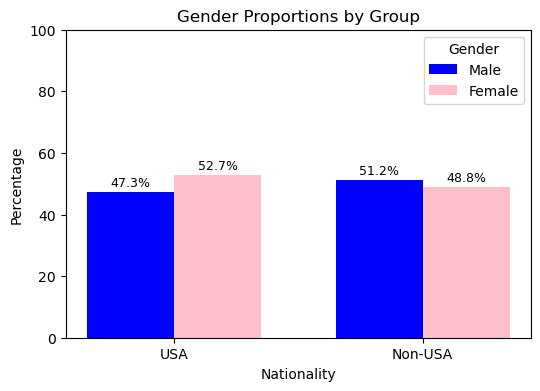

In [99]:
genders = ['Male', 'Female']

groups = ['USA', 'Non-USA']
x = np.arange(len(groups)) 
bar_width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))

bars_male = ax.bar(x - bar_width/2, [gender_counts_usa['Male'], gender_counts_non_usa['Male']], width=bar_width, label='Male', color='blue')

bars_female = ax.bar(x + bar_width/2, [gender_counts_usa['Female'], gender_counts_non_usa['Female']], width=bar_width, label='Female', color='pink')

ax.set_xlabel('Nationality')
ax.set_ylabel('Percentage')
ax.set_title('Gender Proportions by Group')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0, 100)
ax.legend(title='Gender')

for bars in [bars_male, bars_female]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

### Compare Age between American and non-American athletes ###

In [101]:
mean_age_usa = ath_med_gdp[ath_med_gdp['nationality_x'] == 'United States']['age'].mean().round(2)

mean_age_non_usa = ath_med_gdp[ath_med_gdp['nationality_x'] != 'United States']['age'].mean().round(2)

print("Average age of American athletes:", mean_age_usa)
print("Average age of non-American athletes:", mean_age_non_usa)

Average age of American athletes: 26.92
Average age of non-American athletes: 26.97


In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

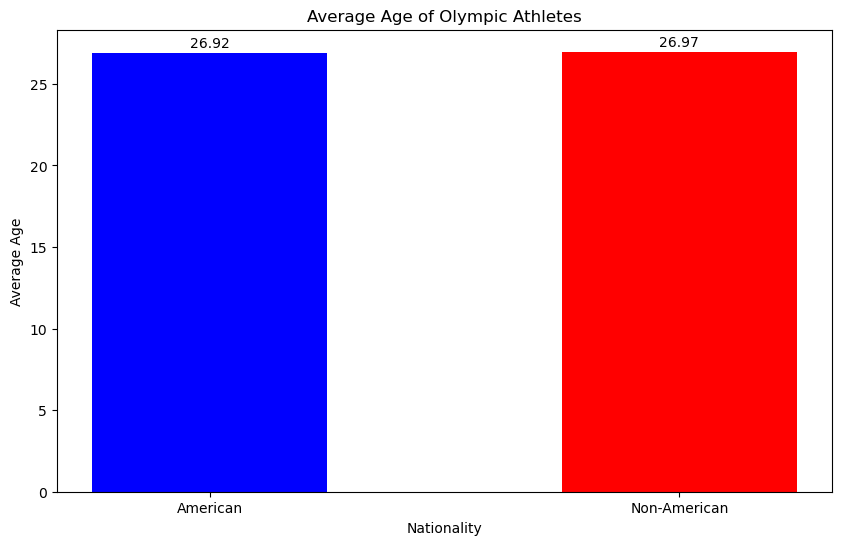

In [103]:
categories = ['American', 'Non-American']
mean_ages = [mean_age_usa, mean_age_non_usa]

plt.figure(figsize=(10, 6))
plt.bar(categories, mean_ages, color=['blue', 'red'],width=0.5)
plt.title('Average Age of Olympic Athletes')
plt.ylabel('Average Age')
plt.xlabel('Nationality')
for i, v in enumerate(mean_ages):
 plt.text(i, v + 1, str(v),
 ha='center', va='top')
plt.show()

### Compare Height between American and non-American athletes ###

In [105]:
mean_height_usa = ath_med_gdp[ath_med_gdp['nationality_x'] == 'United States']['height'].mean().round(2)

mean_height_non_usa = ath_med_gdp[ath_med_gdp['nationality_x'] != 'United States']['height'].mean().round(2)

print("Average height of American athletes:", mean_height_usa, "cm")
print("Average height of non-American athletes:", mean_height_non_usa, "cm")

Average height of American athletes: 95.26 cm
Average height of non-American athletes: 80.89 cm


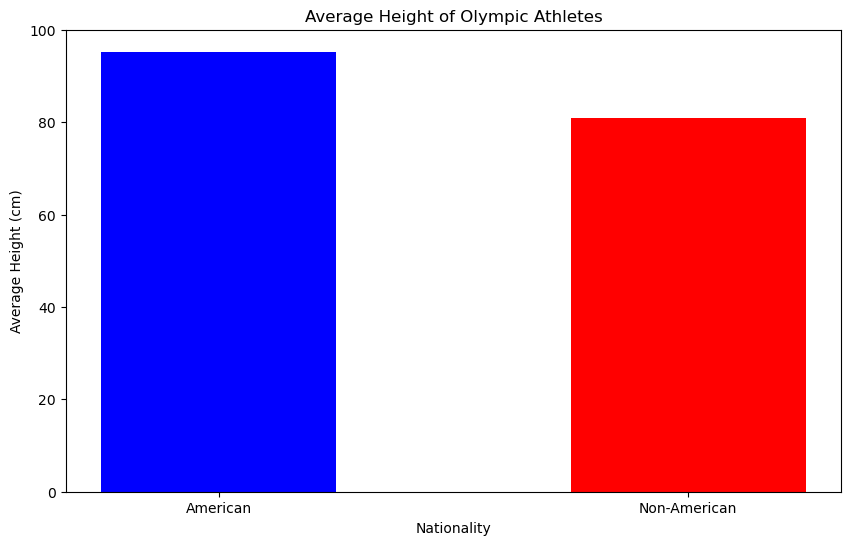

In [106]:
categories = ['American', 'Non-American']
mean_heights = [mean_height_usa, mean_height_non_usa]

plt.figure(figsize=(10, 6))
plt.bar(categories, mean_heights, color=['blue', 'red'],width=0.5)
plt.title('Average Height of Olympic Athletes')
plt.ylabel('Average Height (cm)')
plt.xlabel('Nationality')
plt.show()

### Compare Weight between American and non-American athletes ###

In [108]:
mean_weight_usa = ath_med_gdp[ath_med_gdp['nationality_x'] == 'United States']['weight'].mean().round(2)

mean_weight_non_usa = ath_med_gdp[ath_med_gdp['nationality_x'] != 'United States']['weight'].mean().round(2)

print("Average weight of American athletes:", mean_weight_usa, "kg")
print("Average weight of non-American athletes:", mean_weight_non_usa, "kg")

Average weight of American athletes: 2.96 kg
Average weight of non-American athletes: 2.16 kg


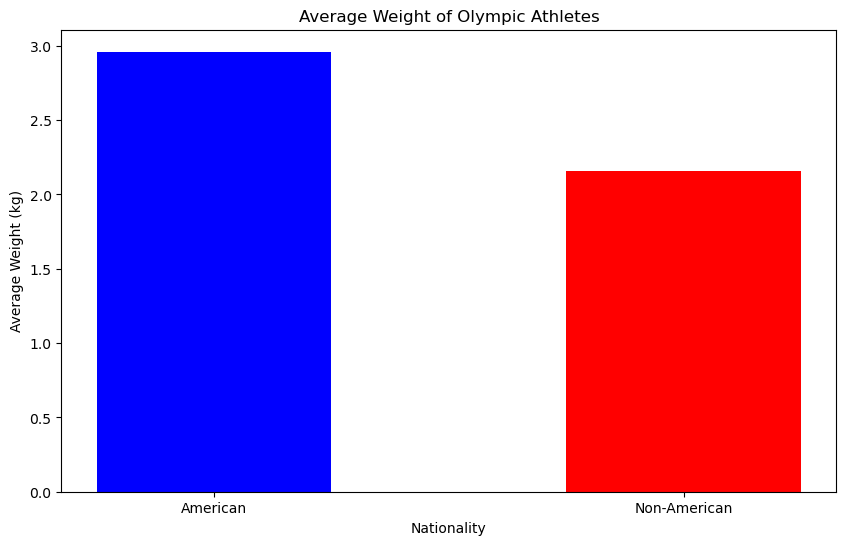

In [109]:
categories = ['American', 'Non-American']
mean_weights = [mean_weight_usa, mean_weight_non_usa]

plt.figure(figsize=(10, 6))
plt.bar(categories, mean_weights, color=['blue', 'red'],width=0.5)
plt.title('Average Weight of Olympic Athletes')
plt.ylabel('Average Weight (kg)')
plt.xlabel('Nationality')
plt.show()

### Which sport types mostly attract youngest 100 athletes and which sport types attract oldest 100 athletes? ###

In [111]:
age_sorted = ath_med_gdp.sort_values(by='age')

youngest_100 = age_sorted.head(100)
oldest_100 = age_sorted.tail(100)

youngest_sports = youngest_100['disciplines'].value_counts()
oldest_sports = oldest_100['disciplines'].value_counts()

print("Most common sports among the youngest 100 athletes:")
print(youngest_sports.head(100)) 

print("\nMost common sports among the oldest 100 athletes:")
print(oldest_sports.head(100))

Most common sports among the youngest 100 athletes:
disciplines
Swimming               35
Skateboarding          23
Artistic Gymnastics    10
Rhythmic Gymnastics     8
Diving                  4
Athletics               3
Shooting                3
Fencing                 3
Table Tennis            2
Sailing                 2
Judo                    1
Surfing                 1
Artistic Swimming       1
Breaking                1
Archery                 1
Football                1
Canoe Sprint            1
Name: count, dtype: int64

Most common sports among the oldest 100 athletes:
disciplines
Equestrian          69
Shooting            15
Table Tennis         6
Athletics            3
Skateboarding        2
Beach Volleyball     1
Golf                 1
Cycling Road         1
Sailing              1
Rowing               1
Name: count, dtype: int64


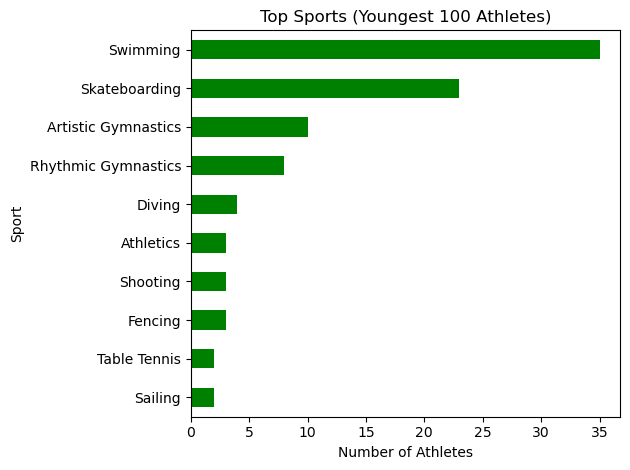

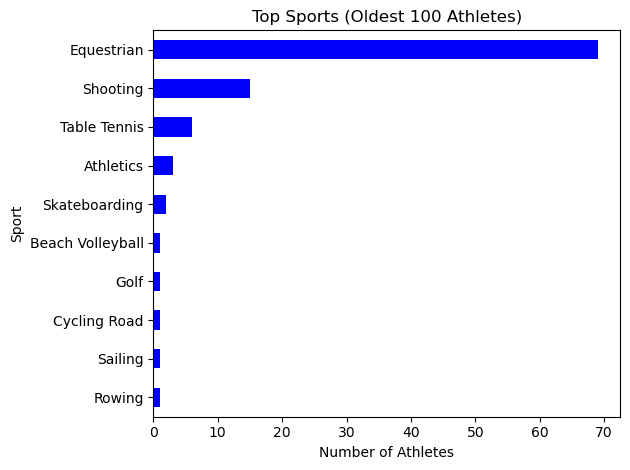

In [112]:
youngest_sports.head(10).plot(kind='barh', color='green', title='Top Sports (Youngest 100 Athletes)')
plt.xlabel("Number of Athletes")
plt.ylabel('Sport')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

oldest_sports.head(10).plot(kind='barh', color='blue', title='Top Sports (Oldest 100 Athletes)')
plt.xlabel("Number of Athletes")
plt.ylabel('Sport')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

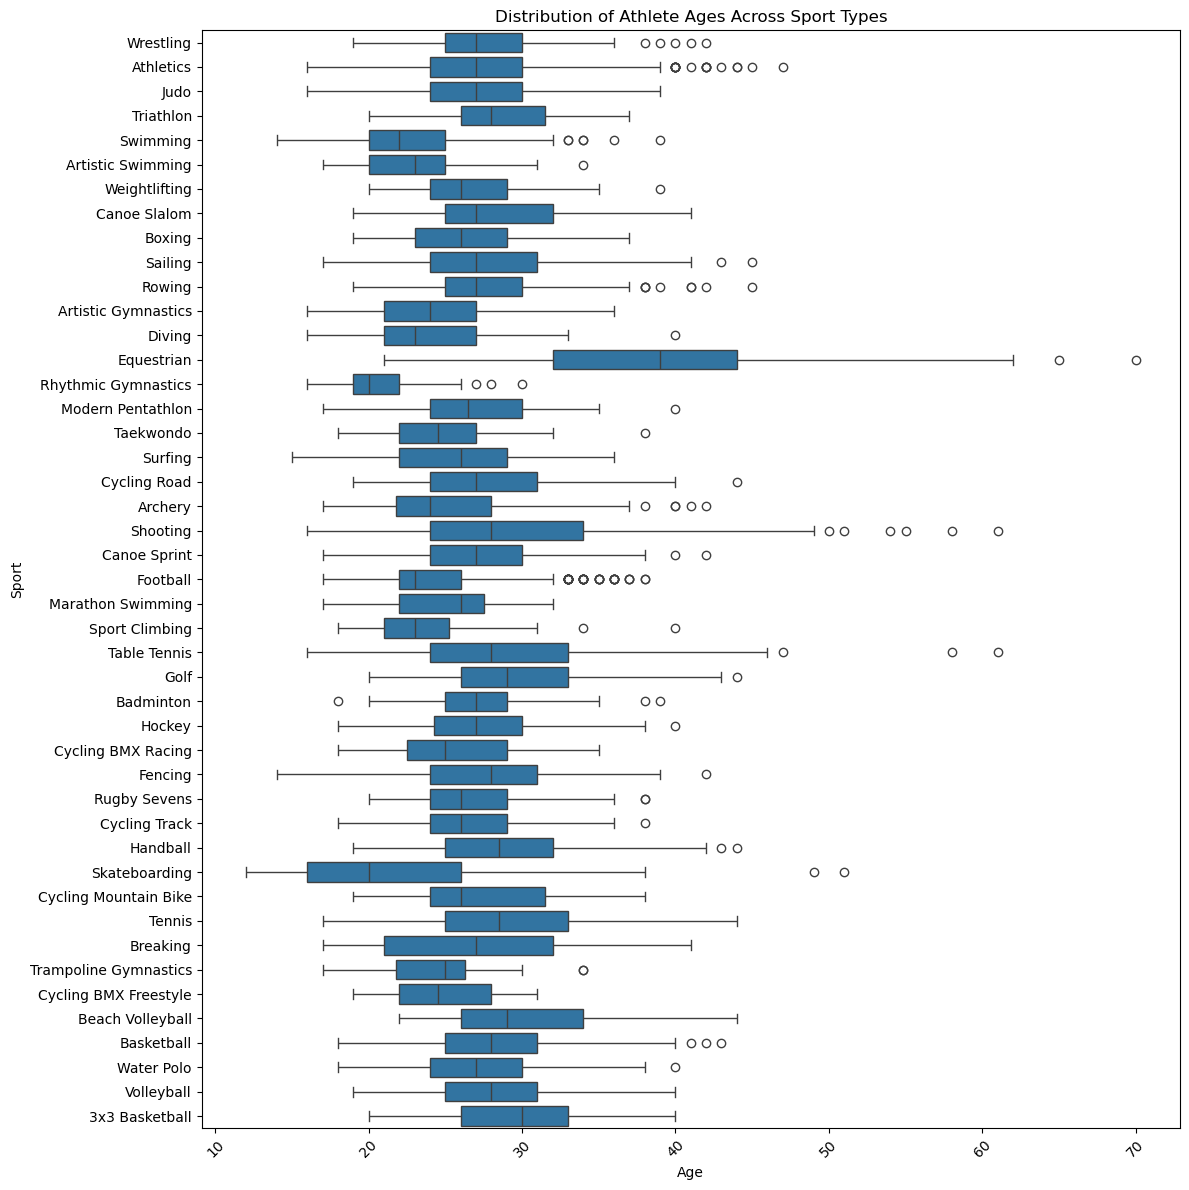

In [113]:
plt.figure(figsize=(12, 12))
sns.boxplot(data=ath_med_gdp, x='age', y='disciplines')

plt.title('Distribution of Athlete Ages Across Sport Types')
plt.xlabel('Age')
plt.ylabel('Sport')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2.4 How many countries participate in each sport type? ###

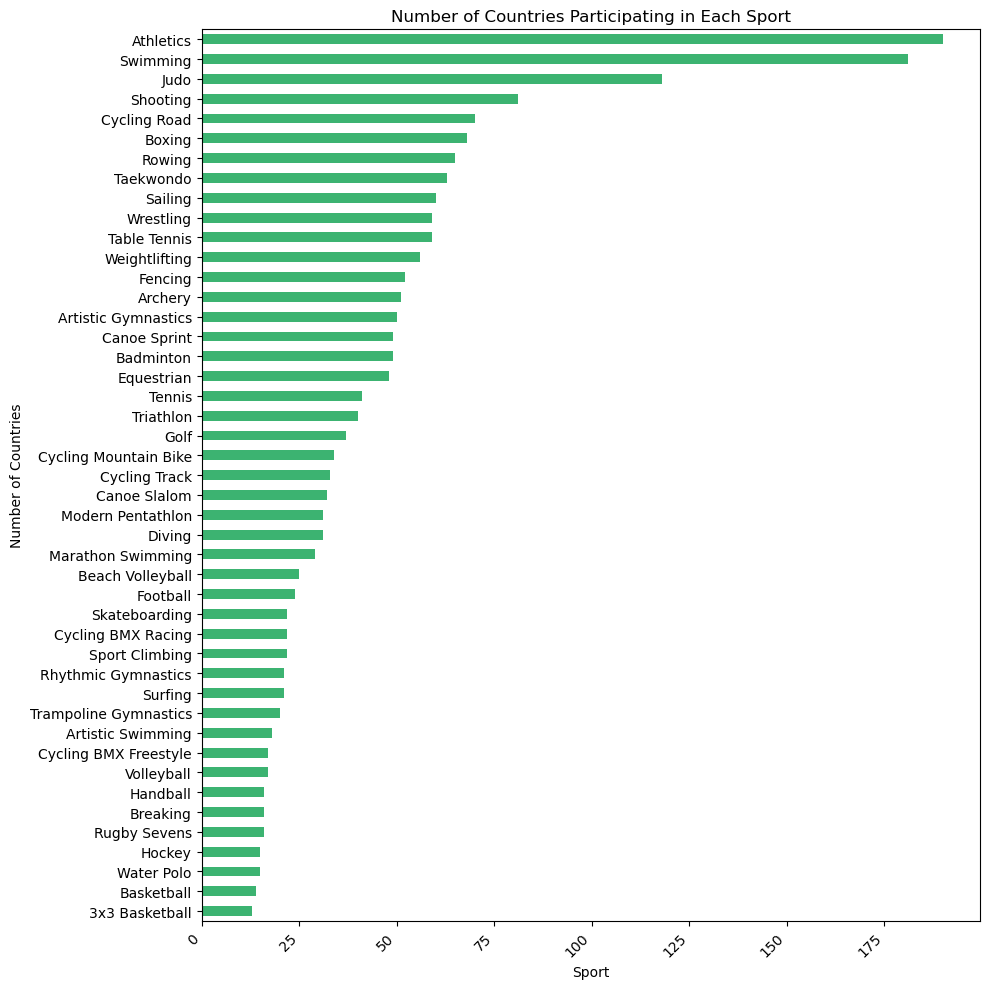

In [115]:
countries_per_sport = ath_med_gdp.groupby('disciplines')['nationality_x'].nunique().sort_values(ascending=True)

countries_per_sport.plot(kind='barh', figsize=(10, 10), color='mediumseagreen')

plt.title('Number of Countries Participating in Each Sport')
plt.xlabel('Sport')
plt.ylabel('Number of Countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.2.4. What are the top 10 and bottom 10 countries in terms of athletes sent to the Olympics? ###

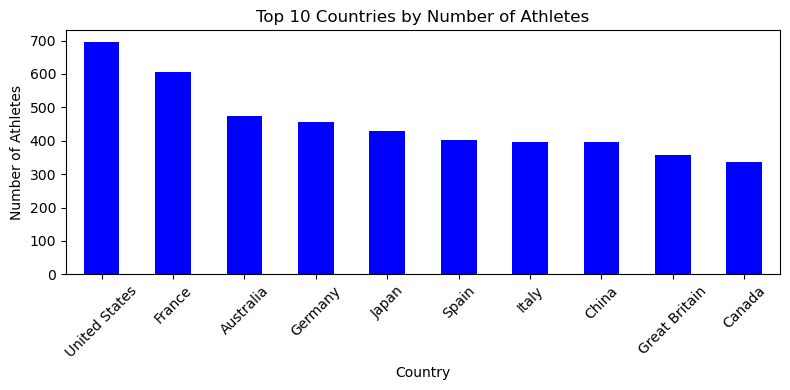

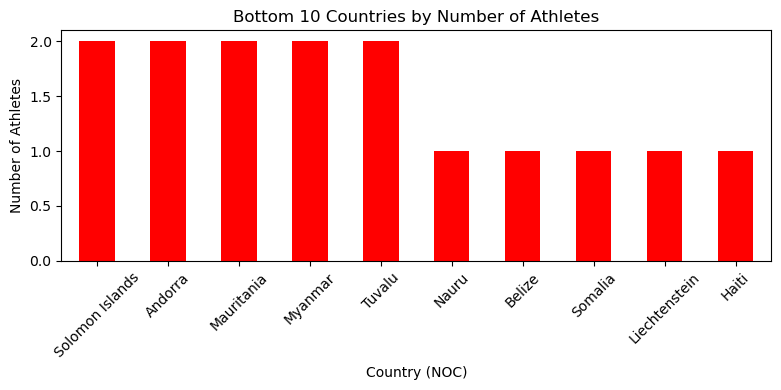

In [117]:
athletes_per_country = ath_med_gdp['nationality_x'].value_counts()

athletes_per_country.head(10).plot(kind='bar', color='blue', figsize=(8, 4))
plt.title('Top 10 Countries by Number of Athletes')
plt.xlabel('Country')
plt.ylabel('Number of Athletes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

athletes_per_country.tail(10).plot(kind='bar', color='red', figsize=(8, 4))
plt.title('Bottom 10 Countries by Number of Athletes')
plt.xlabel('Country (NOC)')
plt.ylabel('Number of Athletes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2.4. Do all the countries send a similar count of athletes (i.e., distribution of athletes sent)? ###

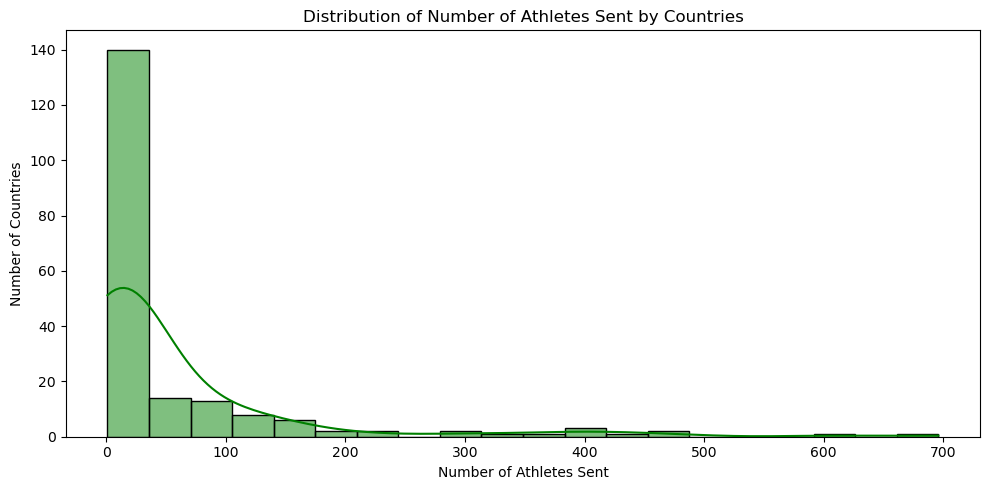

In [119]:
plt.figure(figsize=(10, 5))
sns.histplot(athletes_per_country, bins=20, kde=True, color='green')

plt.title('Distribution of Number of Athletes Sent by Countries')
plt.xlabel('Number of Athletes Sent')
plt.ylabel('Number of Countries')
plt.tight_layout()
plt.show()

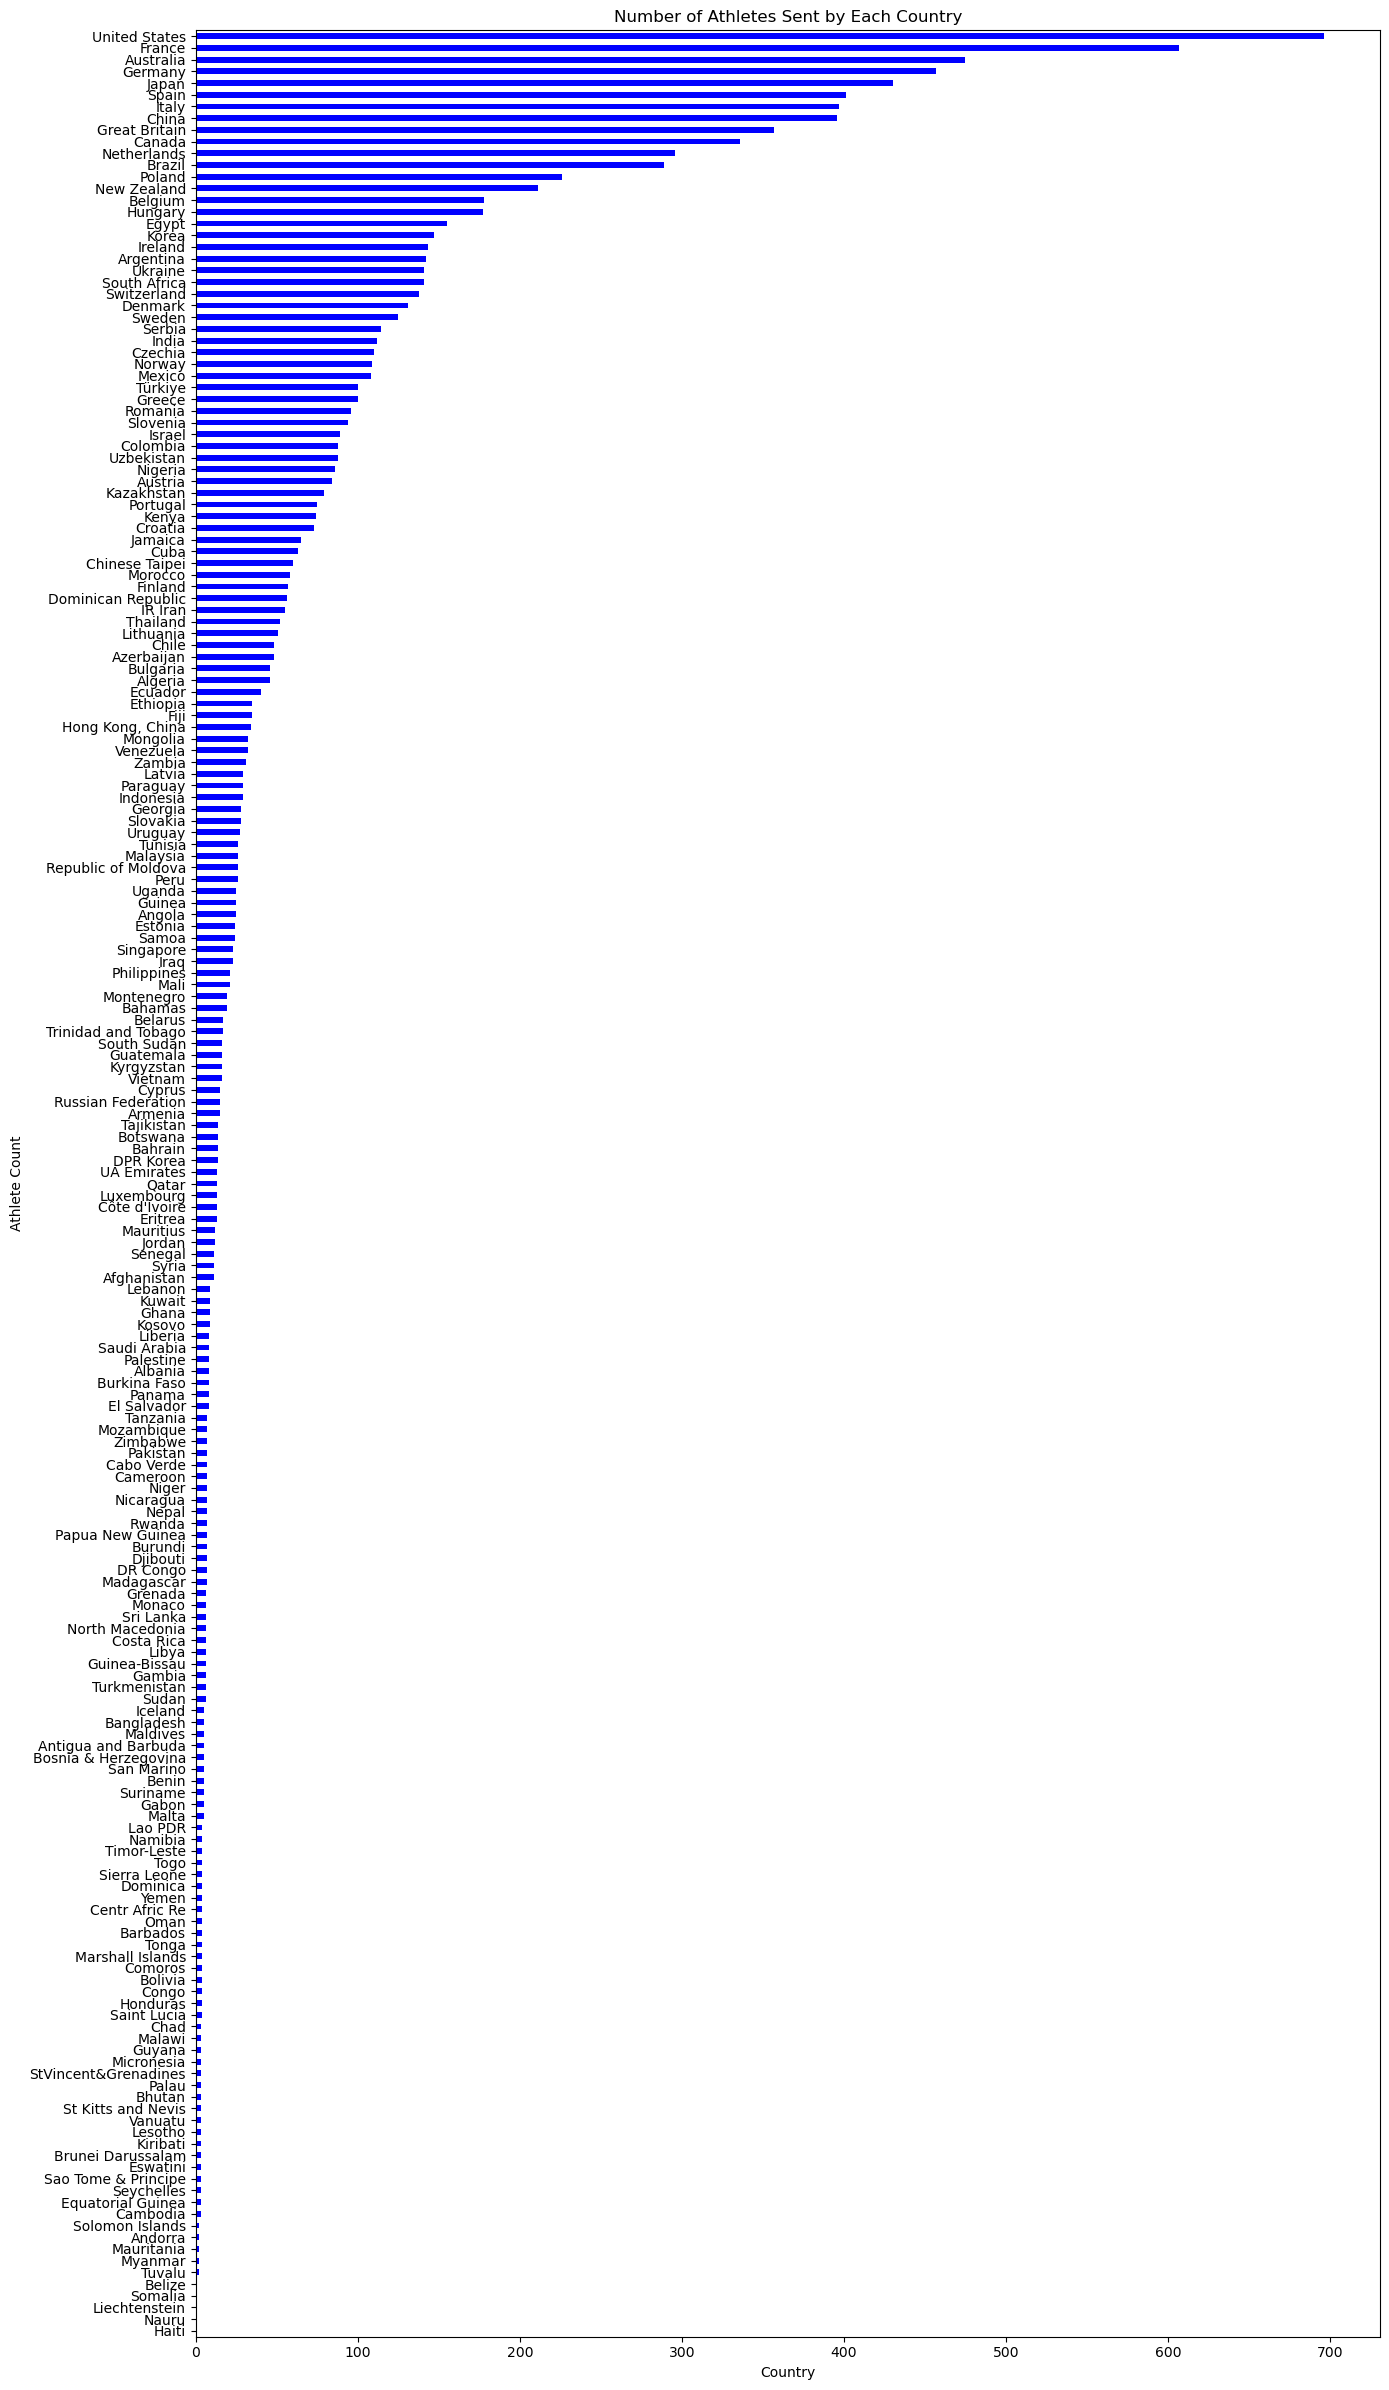

Median number of countries sent: 13.0


In [120]:
sorted_athlete_counts = athletes_per_country.sort_values(ascending=True)

plt.figure(figsize=(14, 24))
sorted_athlete_counts.plot(kind='barh', color='blue')

plt.title('Number of Athletes Sent by Each Country')
plt.xlabel('Country')
plt.ylabel('Athlete Count')
plt.tight_layout()
plt.show()

median_athlete_count = athletes_per_country.median()
print("Median number of countries sent:", median_athlete_count)

### For those countries that send fewer than median count of athletes, what sport types do they compete in? ###

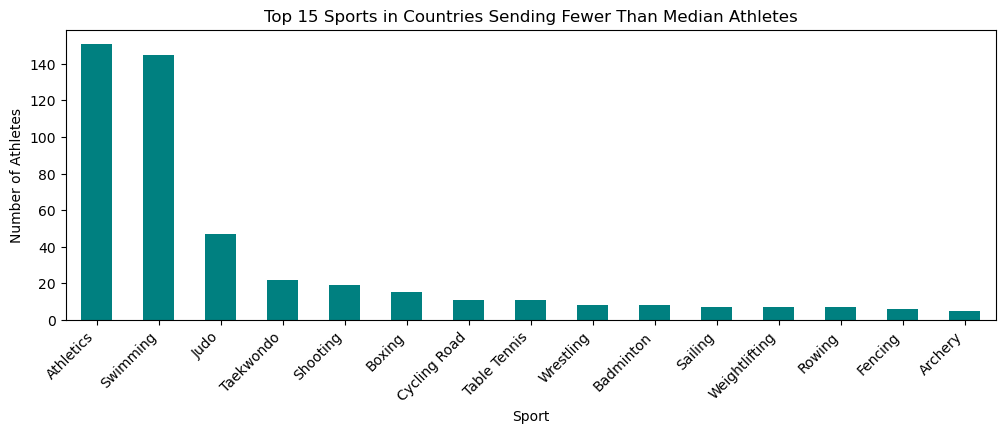

In [122]:
low_athlete_countries = athletes_per_country[athletes_per_country < median_athlete_count].index

df_below_median = ath_med_gdp[ath_med_gdp['nationality_x'].isin(low_athlete_countries)]

sport_counts = df_below_median['disciplines'].value_counts()

plt.figure(figsize=(12, 5))
sport_counts.head(15).plot(kind='bar', color='teal')
plt.title('Top 15 Sports in Countries Sending Fewer Than Median Athletes')
plt.xlabel('Sport')
plt.ylabel('Number of Athletes')
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.3)
plt.show()

### 4.2.5. What does athlete gender distribution look like? How does it compare to the athlete gender distribution of the countries that send more than the median count of athletes? ###


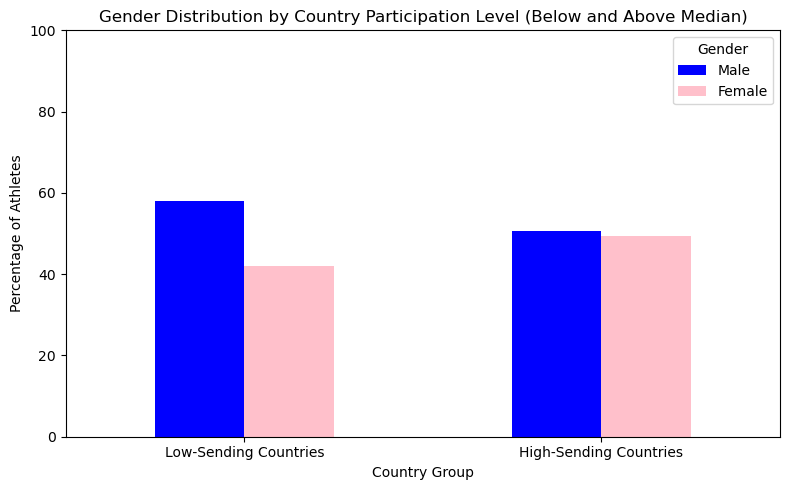

In [124]:
low_athlete_countries = athletes_per_country[athletes_per_country < median_athlete_count].index
high_athlete_countries = athletes_per_country[athletes_per_country >= median_athlete_count].index

df_below_median = ath_med_gdp[ath_med_gdp['nationality_x'].isin(low_athlete_countries)]
df_above_median = ath_med_gdp[ath_med_gdp['nationality_x'].isin(high_athlete_countries)]

low_gender_dist = df_below_median['gender_x'].value_counts(normalize=True) * 100
high_gender_dist = df_above_median['gender_x'].value_counts(normalize=True) * 100

gender_compare = pd.DataFrame({
    'Low-Sending Countries': low_gender_dist,
    'High-Sending Countries': high_gender_dist
})

gender_compare = gender_compare.reindex(['Male', 'Female'])

gender_compare.T.plot(kind='bar', figsize=(8, 5), color=['blue', 'pink'])

plt.title('Gender Distribution by Country Participation Level (Below and Above Median)')
plt.xlabel('Country Group')
plt.ylabel('Percentage of Athletes')
plt.legend(title='Gender')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

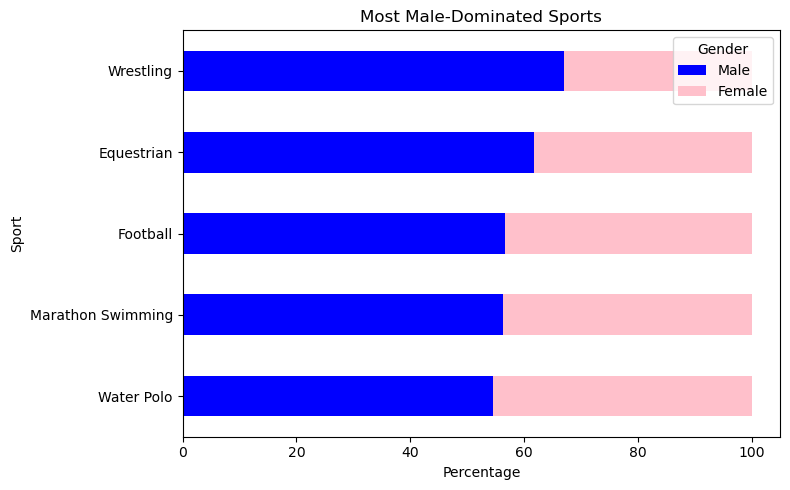

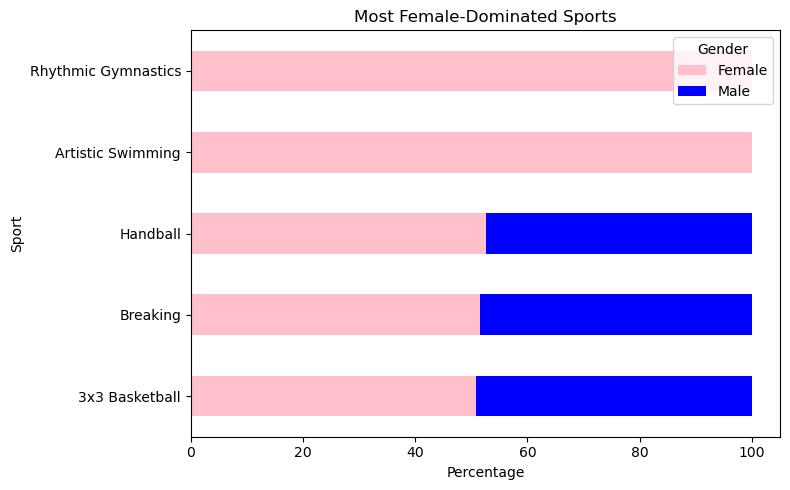

In [125]:
ath_med_gdp['disciplines'] = ath_med_gdp['disciplines'].str.split(r',\s*')
ath_med_gdp = ath_med_gdp.explode('disciplines').reset_index(drop=True)

gender_counts_all = ath_med_gdp.groupby(['disciplines', 'gender_x']).size().unstack(fill_value=0)
gender_percent = gender_counts_all.div(gender_counts_all.sum(axis=1), axis=0) * 100

male_dominated = gender_percent.sort_values(by='Male', ascending=False).head(5)
female_dominated = gender_percent.sort_values(by='Female', ascending=False).head(5)

male_dominated[['Male', 'Female']].plot(kind='barh', stacked=True, figsize=(8, 5), title='Most Male-Dominated Sports', color=['blue','pink'])
plt.xlabel('Percentage')
plt.ylabel('Sport')
plt.gca().invert_yaxis()
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

female_dominated[['Female', 'Male']].plot(kind='barh', stacked=True, figsize=(8, 5), title='Most Female-Dominated Sports', color=['pink', 'blue'])
plt.xlabel('Percentage')
plt.ylabel('Sport')
plt.gca().invert_yaxis()
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [126]:
medallist_df = ath_med_gdp[ath_med_gdp['is_medallist'] == True]

In [127]:
medallist_df

,code,current,name_x,name_short,name_tv,gender_x,function,country_code_x,country_x,country_long_x,nationality_x,nationality_long_x,nationality_code_x,height,weight,disciplines,events,birth_date_x,birth_place,birth_country,residence_place,residence_country,occupation,other_sports,age,medal_type,name_y,gender_y,country_code_y,country_y,country_long_y,nationality_code_y,nationality_y,nationality_long_y,team,team_gender,discipline,event_type,birth_date_y,code_athlete,is_medallist,Country Name,Country Code,2023
0,1532872,True,ALEKSANYAN Artur,ALEKSANYAN A,Artur ALEKSANYAN,Male,Athlete,ARM,Armenia,Armenia,Armenia,Armenia,ARM,0.0,0.0,Wrestling,"[""Men's Greco-Roman 97kg""]",1991-10-21,GYUMRI,Armenia,GYUMRI,Armenia,Athlete,NaN,33,Silver Medal,ALEKSANYAN Artur,Male,ARM,Armenia,Armenia,ARM,Armenia,Armenia,NaN,NaN,Wrestling,HATH,10/21/1991,1532872.0,True,Armenia,ARM,2.408575e+10
1,1532873,True,AMOYAN Malkhas,AMOYAN M,Malkhas AMOYAN,Male,Athlete,ARM,Armenia,Armenia,Armenia,Armenia,ARM,0.0,0.0,Wrestling,"[""Men's Greco-Roman 77kg""]",1999-01-22,YEREVAN,Armenia,YEREVAN,Armenia,NaN,NaN,25,Bronze Medal,AMOYAN Malkhas,Male,ARM,Armenia,Armenia,ARM,Armenia,Armenia,NaN,NaN,Wrestling,HATH,1/22/1999,1532873.0,True,Armenia,ARM,2.408575e+10
32,1535187,True,VERDE ALVAREZ Marco Alonso,VERDE ALVAREZ MA,Marco Alonso VERDE ALVAREZ,Male,Athlete,MEX,Mexico,Mexico,Mexico,Mexico,MEX,180.0,0.0,Boxing,"[""Men's 71kg""]",2002-02-11,MAZATLAN,Mexico,MAZATLAN,Mexico,NaN,NaN,22,Silver Medal,VERDE ALVAREZ Marco Alonso,Male,MEX,Mexico,Mexico,MEX,Mexico,Mexico,NaN,NaN,Boxing,HATH,2/11/2002,1535187.0,True,Mexico,MEX,1.790000e+12
54,1535349,True,OLVERA IBARRA Osmar,OLVERA IBARRA O,Osmar OLVERA IBARRA,Male,Athlete,MEX,Mexico,Mexico,Mexico,Mexico,MEX,0.0,0.0,Diving,"[""Men's 3m Springboard"", ""Men's Synchronised 3...",2004-06-05,MEXICO CITY,Mexico,NaN,NaN,NaN,NaN,20,Bronze Medal,OLVERA IBARRA Osmar,Male,MEX,Mexico,Mexico,MEX,Mexico,Mexico,NaN,NaN,Diving,ATH,6/5/2004,1535349.0,True,Mexico,MEX,1.790000e+12
78,1535420,True,VALENCIA Alejandra,VALENCIA A,Alejandra VALENCIA,Female,Athlete,MEX,Mexico,Mexico,Mexico,Mexico,MEX,0.0,0.0,Archery,"[""Women's Individual"", ""Women's Team"", 'Mixed ...",1994-10-17,HERMOSILLO,Mexico,HERMOSILLO,Mexico,"Athlete, sport soldier",NaN,30,Bronze Medal,VALENCIA Alejandra,Female,MEX,Mexico,Mexico,MEX,Mexico,Mexico,Mexico,W,Archery,HTEAM,10/17/1994,1535420.0,True,Mexico,MEX,1.790000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11002,4654306,True,KIM Woomin,KIM W,KIM Woomin,Male,Athlete,KOR,Korea,Republic of Korea,Korea,Republic of Korea,KOR,0.0,0.0,Swimming,"[""Men's 200m Freestyle"", ""Men's 400m Freestyle...",2001-08-24,BUSAN,Korea,NaN,Korea,Athlete,NaN,23,Bronze Medal,KIM Woomin,Male,KOR,Korea,Republic of Korea,KOR,Korea,Republic of Korea,NaN,NaN,Swimming,ATH,8/24/2001,4654306.0,True,"Korea, Rep.",KOR,1.710000e+12
11014,4663897,True,HARRIES Toby,HARRIES T,Toby HARRIES,Male,Athlete,GBR,Great Britain,Great Britain,Great Britain,Great Britain,GBR,183.0,0.0,Athletics,"[""Men's 4 x 400m Relay""]",1998-09-30,NaN,NaN,NaN,NaN,Athlete,NaN,26,Bronze Medal,HARRIES Toby,Male,GBR,Great Britain,Great Britain,GBR,Great Britain,Great Britain,Great Britain,M,Athletics,TEAM,9/30/1998,4663897.0,True,United Kingdom,GBR,3.380000e+12
11017,4665325,True,BETHUNE Croix,BETHUNE C,Croix BETHUNE,Female,Athlete,USA,United States,United States of America,United States,United States of America,USA,157.0,0.0,Football,['Women'],2001-03-14,NaN,NaN,NaN,NaN,Athlete,NaN,23,Gold Medal,BETHUNE Croix,Female,USA,United States,United States of America,USA,United States,United States of America,United States of America,W,Football,HTEAM,3/14/2001,4665325.0,True,United States,USA,2.770000e+13
11020,4669223,True,BADE Loic,BADE L,Loic BADE,Male,Athlete,FRA,France,France,France,France,FRA,191.0,0.0,Football,['Men'],2000-04-11,SEVRES,France,NaN,Spain,Athle

In [128]:
medallist_df['height'].describe().round(2)

count    2005.00
mean       76.78
std        90.05
min         0.00
25%         0.00
50%         0.00
75%       178.00
max       222.00
Name: height, dtype: float64

In [129]:
us_medallists = medallist_df[medallist_df['nationality_x'] == 'United States']

non_us_medallists = medallist_df[medallist_df['nationality_x'] != 'United States']

In [130]:
us_medallists['height'].describe()

count    255.000000
mean     102.258824
std       91.267948
min        0.000000
25%        0.000000
50%      162.000000
75%      186.000000
max      213.000000
Name: height, dtype: float64

In [131]:
non_us_medallists['height'].describe()

count    1750.000000
mean       73.062286
std        89.292762
min         0.000000
25%         0.000000
50%         0.000000
75%       177.000000
max       222.000000
Name: height, dtype: float64

## 4.4. Statistical Analysis & Hypothesis Testing ##

### 4.4.1. Two-Sample t-Test: Age of Medalists vs. Non-Medalists ###

In [134]:
medallist_ages = ath_med_gdp[ath_med_gdp['is_medallist'] == True]['age']
non_medallist_ages = ath_med_gdp[ath_med_gdp['is_medallist'] != True]['age']

In [135]:
import scipy.stats as stats
import matplotlib.pyplot as plt

t_stat, p_value = stats.ttest_ind(medallist_ages, non_medallist_ages, equal_var=True)

print("T-statistic:", t_stat)
print("p-value:", p_value)

T-statistic: 1.1087100395826113
p-value: 0.26757930856271633
